In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pylab as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")

In [15]:
data=pd.read_csv('ipl.csv')
data.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59


In [21]:
data.isna().sum()


match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [22]:
data.shape

(74, 20)

In [23]:
data.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

Text(0.5, 0, 'number_of_wins')

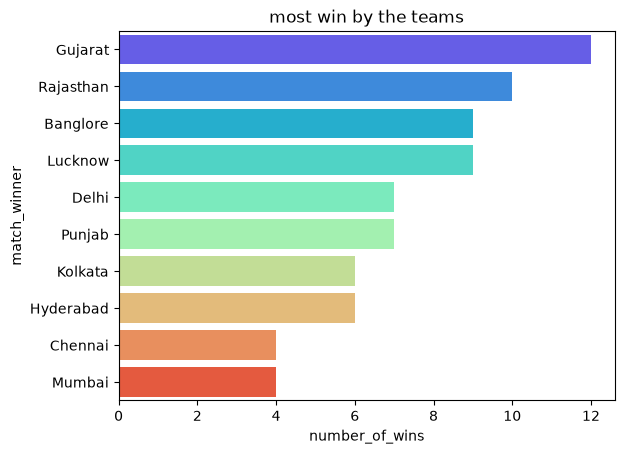

In [31]:
#which team win most matches
matches_win=data['match_winner'].value_counts()
sns.barplot(y=matches_win.index,x=matches_win.values,palette='rainbow')
plt.title('most win by the teams')
plt.xlabel('number_of_wins')

<Axes: xlabel='toss_decision', ylabel='count'>

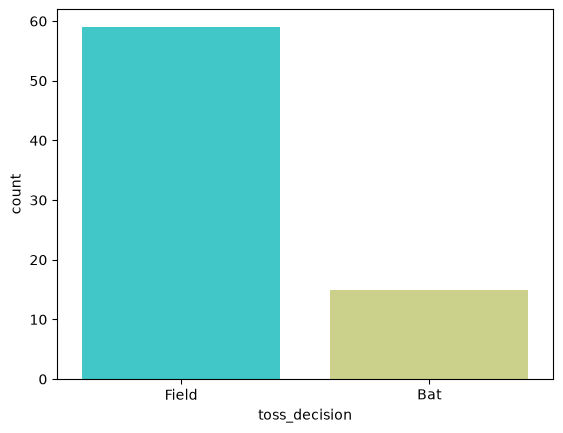

In [38]:
# toss desicion trend
sns.countplot(x=data['toss_decision'],palette='rainbow')

In [47]:
#TOSS WINNER VS MATCH WINNER
toss=len(data[data['toss_winner']==data['match_winner']])
toss
print((toss/data.shape[0])*100)

48.64864864864865


<Axes: xlabel='won_by', ylabel='count'>

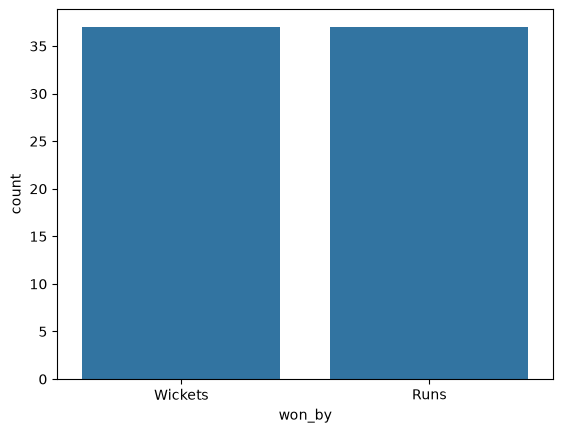

In [48]:
#HOW TEAMS WIN(BY RUNS OR WICKETS)
sns.countplot(x=data['won_by'])

KEY PLAYER PERFORMANCES


<Axes: ylabel='player_of_the_match'>

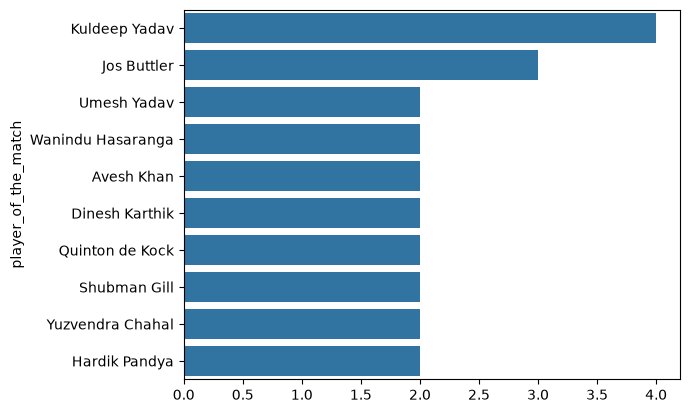

In [57]:

#MOST PLAYER OF THE MATCH AWARD
player=data['player_of_the_match'].value_counts().head(10)
sns.barplot(y=player.index,x=player.values)

In [ ]:
# 2 top scorers
scorers=data[data['highscore']==data['highscore']].sort_values(by='highscore',ascending=False).head(2)['top_scorer']
scorers

65    Quinton de Kock
33        Jos Buttler
Name: top_scorer, dtype: str

<Axes: ylabel='best_bowling'>

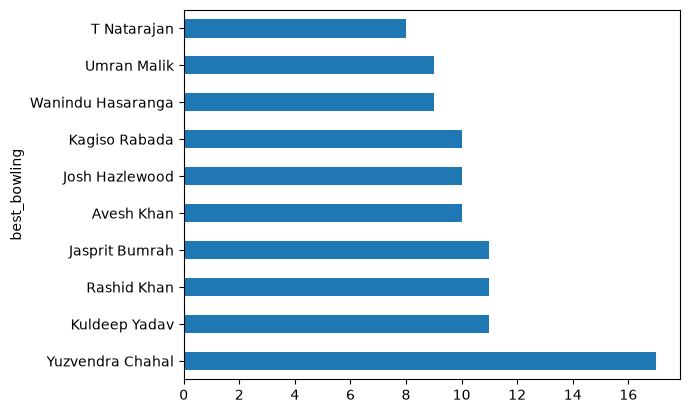

In [92]:

# 10 best bowling figure
data['highest_wickets'] = data['best_bowling_figure'].apply(lambda x :x.split('--')[0])
data['highest_wickets'] = data['highest_wickets'].astype(int)
top_bowlers = data.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

<Axes: ylabel='venue'>

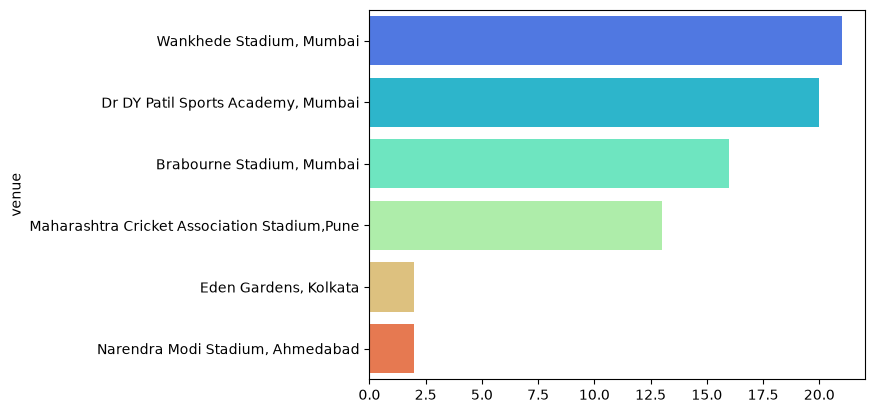

In [97]:
#venue analysis
count=data['venue'].value_counts()
sns.barplot(y=count.index,x=count.values,palette='rainbow')

In [101]:
data.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


<Axes: xlabel='match_winner', ylabel='margin'>

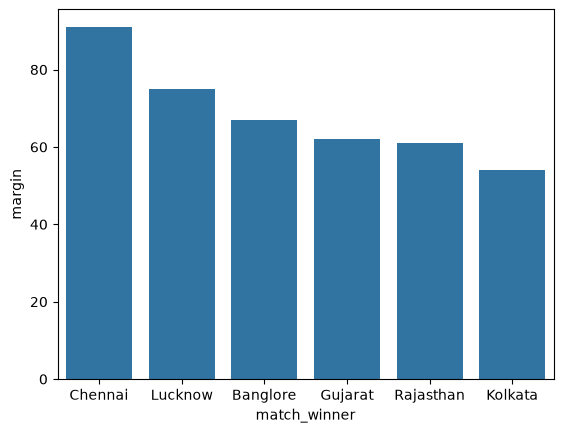

In [116]:
#who win by heighest margin runs
margin=data[data['won_by'] == 'Runs'].sort_values(by = 'margin',ascending=False).head(6)[['match_winner','margin']]
sns.barplot(x=margin.match_winner,y=margin.margin)

In [119]:
data[data['highscore']==data['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [121]:
data[data['highest_wickets'] == data['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
